# Scratch — WP D1 — How much has Germany warmed?
Copy/rename this file to `scratch_<yourname>.ipynb` and work here — not in the main file `klima_analyse.ipynb`.

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("../data/clean/temp_annual_regions.csv")
de = df[["jahr", "Deutschland"]].copy()   # main series for D1, I1, I2
df.head(3)


,jahr,Brandenburg/Berlin,Brandenburg,Baden-Wuerttemberg,Bayern,Hessen,Mecklenburg-Vorpommern,Niedersachsen,Niedersachsen/Hamburg/Bremen,Nordrhein-Westfalen,Rheinland-Pfalz,Schleswig-Holstein,Saarland,Sachsen,Sachsen-Anhalt,Thueringen/Sachsen-Anhalt,Thueringen,Deutschland
0,1881,7.55,7.54,7.66,6.61,7.49,6.96,7.54,7.54,8.14,7.97,7.12,8.28,6.71,7.46,7.11,6.66,7.31
1,1882,8.99,8.97,8.08,7.33,8.25,8.54,8.88,8.88,9.03,8.55,8.78,8.79,8.12,8.81,8.35,7.77,8.34
2,1883,8.42,8.41,7.77,6.85,7.96,7.95,8.39,8.39,8.71,8.26,8.18,8.51,7.46,8.32,7.87,7.31,7.88


**Task:** Time series (column Deutschland) + 10-year moving average, plus decadal anomaly vs. 1961–1990.

Template: `projekt_schritte.md` Block 2. Save figures to `../figures/` as `fig1_*.png / fig2_*.png`.

In [15]:
# ma10 = 10-year moving average
de["ma10"] = de["Deutschland"].rolling(10).mean()

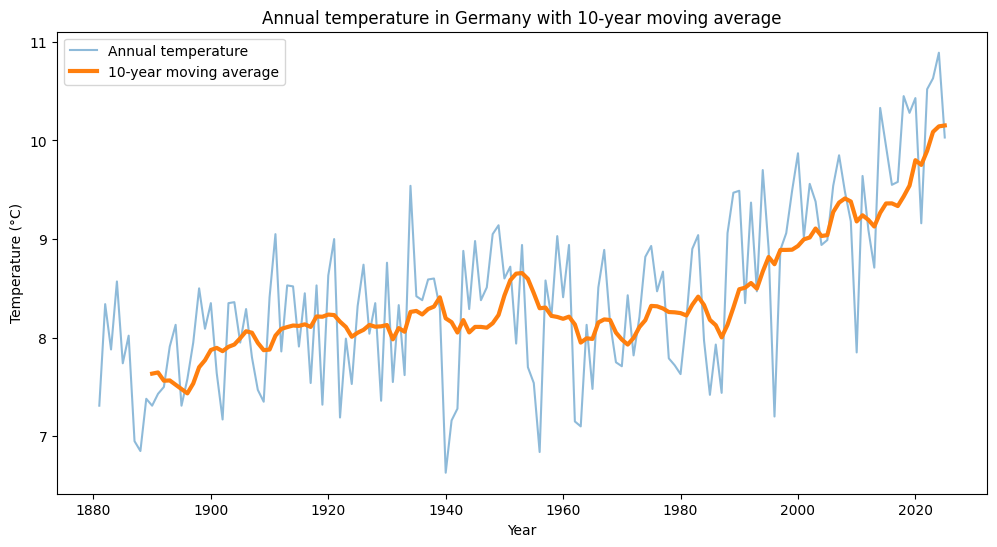

In [16]:
plt.figure(figsize=(12, 6))

plt.plot(de["jahr"], de["Deutschland"], alpha=0.5, label="Annual temperature")
plt.plot(de["jahr"], de["ma10"], linewidth=3, label="10-year moving average")

plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.title("Annual temperature in Germany with 10-year moving average")
plt.legend()

plt.show()

In [17]:
#Dekadendurschnitte 
de["decade"]=(de["jahr"]//10)*10
groups = de.groupby("decade")["Deutschland"]
means = groups.mean()
decadal = means.reset_index()
decadal.head()

,decade,Deutschland
0,1880,7.671111
1,1890,7.771000
2,1900,7.873000
3,1910,8.212000
4,1920,8.115000


In [19]:
# mean temperature of the reference period 1961-1990
reference = de[(de["jahr"]>= 1961)&(de["jahr"]<=1990)]["Deutschland"].mean()

decadal["anomaly"] = decadal["Deutschland"] - reference
decadal.head()

,decade,Deutschland,anomaly
0,1880,7.671111,-0.569222
1,1890,7.771000,-0.469333
2,1900,7.873000,-0.367333
3,1910,8.212000,-0.028333
4,1920,8.115000,-0.125333


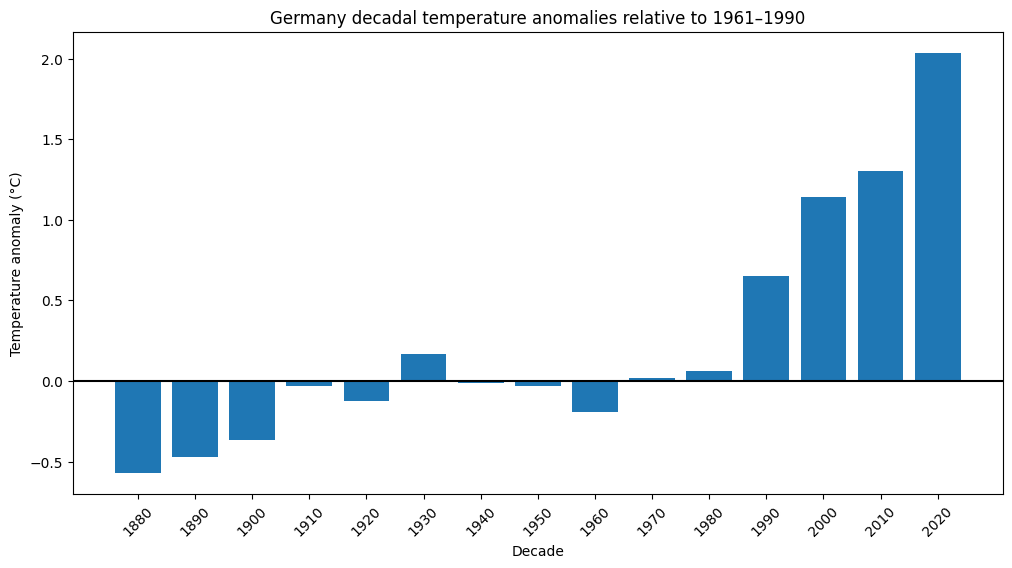

In [20]:
plt.figure(figsize=(12, 6))

plt.bar(decadal["decade"].astype(str), decadal["anomaly"])
plt.axhline(y=0, color="black")

plt.xlabel("Decade")
plt.ylabel("Temperature anomaly (°C)")
plt.title("Germany decadal temperature anomalies relative to 1961–1990")
plt.xticks(rotation=45)

plt.show()

In [24]:
erste_periode = de[(de["jahr"]>= 1881)&(de["jahr"]<=1910)]["Deutschland"].mean()

last_decade = de[de["jahr"] >= de["jahr"].max() - 9]["Deutschland"].mean()

erwärmung = last_decade - erste_periode

print(f"The last decade was about {erwärmung:.1f} °C warmer than 1881–1910.")

The last decade was about 2.4 °C warmer than 1881–1910.
